In [1]:
import numpy as np 
import pandas as pd
from src import utils
import matplotlib.pyplot as plt
from datetime import datetime
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [47]:
def get_interp_speed(m1):
    #compute speed
    df = utils.get_movement_df(m1)
    ntrials = df["trial"].astype(int).max()
    speed_interp = np.empty((ntrials, 400))
    #interp speed to 400 positions
    for trial_no in df["trial"].unique():
        trial_no = int(trial_no)
        # This value depends on the wheel... some encoders where dm others cm... etc.. speed should be around 20 to 60 cm/s on avg 
        # can be negative or positive depending if the wheel returned positive or negative values when the mouse moves forward (most likely all your mice share the same val)
        trial_speed = df.query(f"trial == {trial_no}")["pitch"].values * -10 #THIS
        trial_distance = df.query(f"trial == {trial_no}")["distance"].values
        speed_interp[trial_no-1] = np.interp(np.arange(400), trial_distance, trial_speed)
    return speed_interp

from datetime import datetime, timedelta
def get_lick_df(MouseObject, drop_last_trial=True):
    if "TX" in MouseObject.name:
        df = pd.DataFrame(MouseObject._timeline["Licks"].T, columns=["trial", "distance","alpha","is_rewarded","time", "flag"])
    else:
        df = pd.DataFrame(MouseObject._timeline["Licks"].T, columns=["trial", "distance","alpha","is_rewarded","time", "flag", "istest"])
    df["datetime"] = pd.to_datetime(
        df["time"].apply(
            lambda x: datetime.fromordinal(int(x))
            + timedelta(days=x % 1)
            - timedelta(days=366)
        )
    )
    df = df.assign(distance = df["distance"]*10)
    df = df.assign(date=df["datetime"].dt.date)
    df = df.assign(hour_min_sec=df["datetime"].dt.time)
    df = df.assign(seconds_in_session=(df["datetime"] - df["datetime"][0]).dt.total_seconds())
    if drop_last_trial:
        n_trials = df.trial.unique()[-2].astype(int)
        df = df.loc[df.trial != df.trial.max()]
    else:
        n_trials = df.trial.unique()[-1].astype(int)
    isrewarded = MouseObject._timeline['TrialRewardStrct'].flatten()[:n_trials]
    isnew = MouseObject._timeline['TrialNewTextureStrct'].flatten()[:n_trials]
    trial_type , _ = utils.get_trial_categories(isrewarded, isnew)
    for ix, ttype in enumerate(trial_type):
        df.loc[df.trial == ix+1, "trial_type"] = ttype
    df.drop(["time","datetime","is_rewarded","alpha"], axis=1, inplace=True)
    return df

def sliding_window_avg(arr, window_size):
    """
    Compute sliding window average and pad values at the end.

    Parameters:
        arr (array-like): Input numeric sequence.
        window_size (int): Size of the moving window (must be >= 1).

    Returns:
        np.ndarray: Averaged array with padding at the end.
    """
    # Convert to NumPy array
    arr = np.asarray(arr, dtype=float)

    # Validate inputs
    if window_size < 1:
        raise ValueError("window_size must be >= 1")
    if window_size > len(arr):
        raise ValueError("window_size cannot be larger than array length")

    # Compute moving average using convolution
    kernel = np.ones(window_size) / window_size
    avg_values = np.convolve(arr, kernel, mode='valid')

    # Pad the end with the last computed average
    pad_length = len(arr) - len(avg_values)
    if pad_length > 0:
        avg_values = np.concatenate([avg_values, np.full(pad_length, avg_values[-1])])

    return avg_values

In [3]:
name = "JH2"
date = "2024_08_02"
blk = "1"
m = utils.load_mouse(name, date, blk, load_neurons=False, interp_behav=False, load_retinotopy=False)

Checking if model object exists ...
Timeline with fname: Timeline_JH2_2024_08_02_1.mat not found, trying with fname: JH2_2024_08_02_1.mat 
Timeline file is in v7.3 format, loading with h5py


In [10]:
m._timeline.keys()

dict_keys(['Licks', 'Movement', 'RewardInfo', 'TrainTrialStrct', 'TrialCatchStrct', 'TrialDuration', 'TrialNewTextureStrct', 'TrialRewardStrct', 'displacement', 'manual'])

In [ ]:
df = utils.get_movement_df(m)
ntrials = df["trial"].astype(int).max()
categories = m._timeline["TrialRewardStrct"].astype(bool).squeeze() #to what category each trial belongs
categories = categories[:ntrials]

In [46]:
speed_interp = get_interp_speed(m)
licks = get_lick_df(m, drop_last_trial=True)

In [49]:
licks_trial = licks.query("trial == 10")["distance"].values

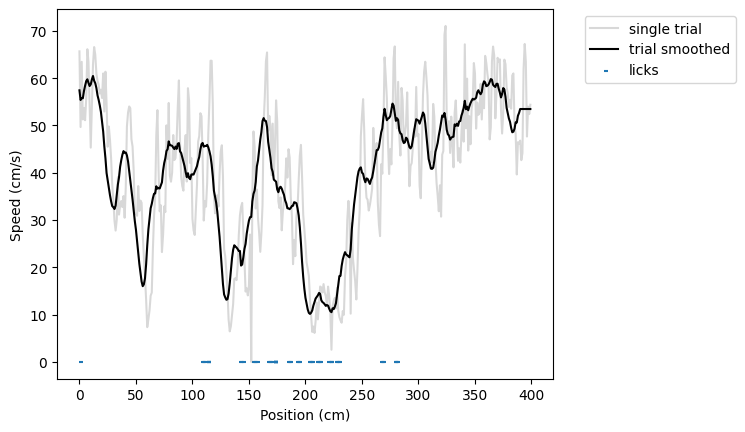

In [63]:
plt.plot(speed_interp[10], color='gray', alpha=.3 , label = 'single trial')
plt.plot(sliding_window_avg(speed_interp[10], window_size=10), color='black' , label = 'trial smoothed')
plt.scatter(licks_trial, np.full_like(licks_trial, 0), s=10, marker=1, label='licks')
plt.xlabel('Position (cm)')
plt.ylabel('Speed (cm/s)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

Overall

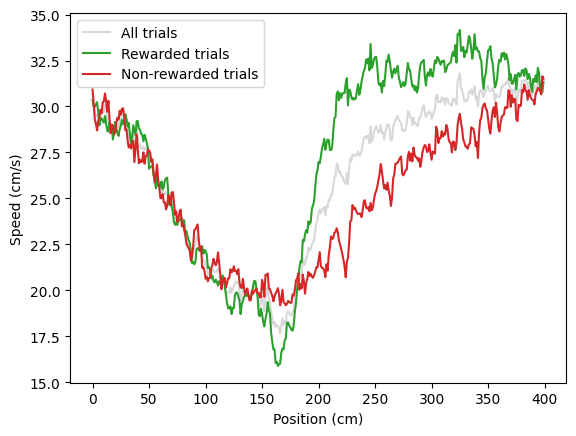

In [ ]:
plt.plot(speed_interp.mean(0), color='gray', alpha=.3 , label = 'All trials')
plt.plot(speed_interp[categories].mean(0), color='tab:green' , label = 'Rewarded trials')
plt.plot(speed_interp[~categories].mean(0), color='tab:red' , label = 'Non-rewarded trials')
plt.xlabel('Position (cm)')
plt.ylabel('Speed (cm/s)')
plt.legend()

If you want it prettier:

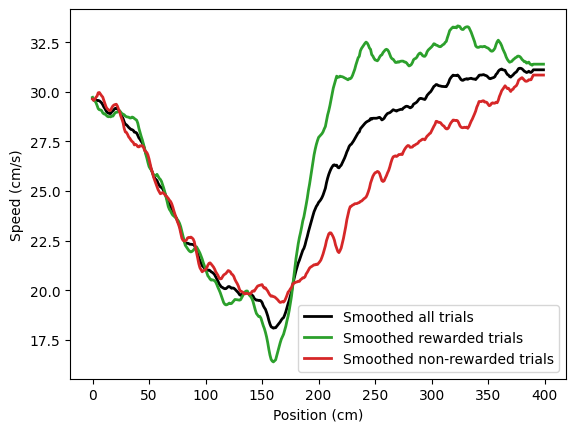

In [44]:
window_size = 10
speed_smooth = sliding_window_avg(speed_interp.mean(0), window_size=window_size)
rew_smooth = sliding_window_avg(speed_interp[categories].mean(0), window_size=window_size)
nonrew_smooth = sliding_window_avg(speed_interp[~categories].mean(0), window_size=window_size)
plt.plot(speed_smooth, color='black', linewidth=2, label='Smoothed all trials')
plt.plot(rew_smooth, color='tab:green', linewidth=2, label='Smoothed rewarded trials')
plt.plot(nonrew_smooth, color='tab:red', linewidth=2, label='Smoothed non-rewarded trials')
plt.xlabel('Position (cm)')
plt.ylabel('Speed (cm/s)')
plt.legend()